# Spark Data Lake — Medallion Architecture Demo

Interactive walkthrough of a batch CDC (Change Data Capture) pipeline: Raw → Bronze → Silver → Gold.

**Prerequisites** — from the project root:

```
make up
make run
```

Then open this notebook in Jupyter (http://localhost:8889) or PyCharm and run all cells.

## 1. Architecture and skills demonstrated

```
Generator (JSON, CDC)  →  raw/  →  Bronze (Delta)
                              ↓
                         Silver (SCD2 + DQ)
                              ↓
                         Gold (monthly KPIs)
```

| Layer | Purpose | Key techniques |
|-------|---------|------------------|
| Raw | Landing zone in MinIO | Hive-style partitions `dt=YYYY-MM-DD` |
| Bronze | Immutable ingest | Incremental checkpoint, dedup, corrupt JSON routing |
| Silver | Curated facts | CDC (Change Data Capture), SCD2 (Slowly Changing Dimension Type 2), DQ (Data Quality), DQE (Data Quality Exceptions) |
| Gold | Business metrics | MRR (Monthly Recurring Revenue), active / new / canceled subs by month and plan |

Stack: Apache Spark 3.5, Delta Lake 3.0, MinIO (S3-compatible object storage), Docker Compose.

In [1]:
import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count


def _quiet_spark_loggers(spark_session):
    log4j = spark_session._jvm.org.apache.log4j
    level = log4j.Level.ERROR
    for name in (
        "org.apache.hadoop.metrics2.impl.MetricsConfig",
        "org.apache.hadoop.metrics2",
        "org.apache.spark.sql.catalyst.util.SparkStringUtils",
        "org.apache.hadoop.util.NativeCodeLoader",
    ):
        log4j.LogManager.getLogger(name).setLevel(level)


S3_ENDPOINT = os.getenv("S3_ENDPOINT", "http://minio:9000")
S3_ACCESS_KEY = os.getenv("S3_ACCESS_KEY", "minioadmin")
S3_SECRET_KEY = os.getenv("S3_SECRET_KEY", "minioadmin")

RAW_PATH = "s3a://data-lake/raw/"
BRONZE_PATH = "s3a://data-lake/bronze/"
SILVER_PATH = "s3a://data-lake/silver/"
GOLD_PATH = "s3a://data-lake/gold/"
DQE_PATH = "s3a://data-lake/dqe_errors/"
BRONZE_DQE_PATH = "s3a://data-lake/dqe_bronze/"

spark = (
    SparkSession.builder.appName("MedallionNotebook")
    .master("local[*]")
    .config("spark.hadoop.fs.s3a.endpoint", S3_ENDPOINT)
    .config("spark.hadoop.fs.s3a.access.key", S3_ACCESS_KEY)
    .config("spark.hadoop.fs.s3a.secret.key", S3_SECRET_KEY)
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
    .config("spark.sql.debug.maxToStringFields", "200")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
_quiet_spark_loggers(spark)
logging.getLogger("py4j").setLevel(logging.ERROR)
print(
    "Spark session ready\n"
    f"  master=local[*]  (all CPU cores in this Jupyter container — not the Spark cluster)\n"
    f"  MinIO endpoint={S3_ENDPOINT}  (Docker network hostname; correct inside the jupyter container)\n"
    f"  Spark UI: http://localhost:4040  (while this session is active)"
)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/30 07:57:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session ready
  master=local[*]  (all CPU cores in this Jupyter container — not the Spark cluster)
  MinIO endpoint=http://minio:9000  (Docker network hostname; correct inside the jupyter container)
  Spark UI: http://localhost:4040  (while this session is active)


## 2. Bronze — incremental ingest from raw JSON

Bronze stores parsed CDC events as Delta, partitioned by `dt` (event date).
The pipeline adds `ingest_timestamp`, `source_file`, and `event_dedup_key` for idempotent replays.

In [2]:
bronze_df = spark.read.format("delta").load(BRONZE_PATH)

print(f"Bronze rows: {bronze_df.count()}")
bronze_df.printSchema()
bronze_df.select(
    "subscription_id", "operation", "timestamp", "plan_type", "price",
    "dt", "ingest_timestamp", "source_file"
).show(5, truncate=False)


Bronze rows: 450
root
 |-- operation: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- subscription_id: string (nullable = true)
 |-- user_id: long (nullable = true)
 |-- plan_type: string (nullable = true)
 |-- price: double (nullable = true)
 |-- billing_cycle: string (nullable = true)
 |-- status: string (nullable = true)
 |-- auto_renew: boolean (nullable = true)
 |-- start_date: string (nullable = true)
 |-- cancel_date: string (nullable = true)
 |-- updated_at: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- ingest_timestamp: timestamp (nullable = true)
 |-- event_ts: timestamp (nullable = true)
 |-- source_file: string (nullable = true)
 |-- event_dedup_key: string (nullable = true)
 |-- dt: date (nullable = true)

+---------------+---------+--------------------+---------+-----+----------+-------------------------+-------------------------------------------------------------------+
|subscription_id|operation|timestamp           |plan_t

In [3]:
print("Partition distribution (dt):")
bronze_df.groupBy("dt").count().orderBy("dt").show(30)

try:
    bronze_dqe = spark.read.format("delta").load(BRONZE_DQE_PATH)
    print(f"Corrupt JSON routed to dqe_bronze/: {bronze_dqe.count()} rows")
except Exception:
    print("No dqe_bronze/ table (generator produced only valid JSON in this run)")


Partition distribution (dt):
+----------+-----+
|        dt|count|
+----------+-----+
|2025-01-01|   50|
|2025-01-02|   50|
|2025-01-03|   50|
|2025-02-01|   50|
|2025-02-02|   50|
|2025-02-03|   50|
|2025-03-01|   50|
|2025-03-02|   50|
|2025-03-03|   50|
+----------+-----+

No dqe_bronze/ table (generator produced only valid JSON in this run)


## 3. Silver — SCD2 and DQ

Valid Bronze rows pass DQ rules (price > 0, valid plan/status, user_id not null).
Invalid rows are written to `dqe_errors/` (DQE — Data Quality Exceptions).

Silver keeps version history per subscription: `valid_from`, `valid_to`, `is_current`.

In [4]:
silver_df = spark.read.format("delta").load(SILVER_PATH)

print(f"Silver rows (all versions): {silver_df.count()}")
print(f"Current subscriptions: {silver_df.filter(col('is_current')).count()}")
silver_df.printSchema()


Silver rows (all versions): 88
Current subscriptions: 88
root
 |-- subscription_id: string (nullable = true)
 |-- user_id: long (nullable = true)
 |-- plan_type: string (nullable = true)
 |-- price: double (nullable = true)
 |-- billing_cycle: string (nullable = true)
 |-- status: string (nullable = true)
 |-- auto_renew: boolean (nullable = true)
 |-- start_date: string (nullable = true)
 |-- cancel_date: string (nullable = true)
 |-- operation: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- valid_from: timestamp (nullable = true)
 |-- valid_to: timestamp (nullable = true)
 |-- is_current: boolean (nullable = true)
 |-- ingest_timestamp: timestamp (nullable = true)
 |-- source_file: string (nullable = true)
 |-- dt: date (nullable = true)



In [5]:
multi_version = silver_df.groupBy("subscription_id").count().filter(col("count") > 1)
example_sub = multi_version.first()

if example_sub:
    sub_id = example_sub["subscription_id"]
    print(f"SCD2 history for {sub_id}:")
    silver_df.filter(col("subscription_id") == sub_id).select(
        "subscription_id", "plan_type", "price", "status",
        "valid_from", "valid_to", "is_current", "operation"
    ).orderBy("valid_from").show(truncate=False)
else:
    print("No multi-version subscriptions — sample current rows:")
    silver_df.filter(col("is_current")).select(
        "subscription_id", "plan_type", "price", "status",
        "valid_from", "valid_to", "is_current"
    ).show(5, truncate=False)


No multi-version subscriptions — sample current rows:
+---------------+---------+-----+--------+-------------------+--------+----------+
|subscription_id|plan_type|price|status  |valid_from         |valid_to|is_current|
+---------------+---------+-----+--------+-------------------+--------+----------+
|sub_abc20      |family   |43.18|past_due|2025-03-03 03:44:10|NULL    |true      |
|sub_abc24      |family   |45.77|active  |2025-03-03 04:22:44|NULL    |true      |
|sub_abc26      |family   |28.67|canceled|2025-03-03 20:12:50|NULL    |true      |
|sub_abc32      |family   |14.15|active  |2025-03-03 15:25:36|NULL    |true      |
|sub_abc38      |family   |23.88|canceled|2025-03-02 00:42:52|NULL    |true      |
+---------------+---------+-----+--------+-------------------+--------+----------+
only showing top 5 rows



In [6]:
print("Partition distribution (plan_type):")
silver_df.groupBy("plan_type").count().orderBy("plan_type").show()

try:
    dqe_df = spark.read.format("delta").load(DQE_PATH)
    print(f"DQ failures in dqe_errors/: {dqe_df.count()} rows")
    dqe_df.select("subscription_id", "plan_type", "price", "status", "user_id").show(5, truncate=False)
except Exception as exc:
    print("Could not read dqe_errors/:", exc)


Partition distribution (plan_type):
+---------+-----+
|plan_type|count|
+---------+-----+
|    basic|   22|
|   family|   33|
|  premium|   33|
+---------+-----+

DQ failures in dqe_errors/: 43 rows
+---------------+------------+-----+--------+-------+
|subscription_id|plan_type   |price|status  |user_id|
+---------------+------------+-----+--------+-------+
|sub_abc72      |family      |0.0  |active  |54     |
|sub_abc48      |invalid_plan|46.05|past_due|55     |
|sub_abc40      |invalid_plan|42.21|paused  |64     |
|sub_abc84      |family      |5.26 |unknown |24     |
|sub_abc30      |invalid_plan|16.3 |active  |36     |
+---------------+------------+-----+--------+-------+
only showing top 5 rows



## 4. Gold — monthly subscription KPIs

Gold aggregates point-in-time metrics from full SCD2 history:
`total_active_subs`, `mrr`, `new_subs_count`, `canceled_subs_count`
by `year_month` and `plan_type`.

In [7]:
gold_df = spark.read.format("delta").load(GOLD_PATH)

gold_df.orderBy("year_month", "plan_type").show(truncate=False)
months = [r.year_month for r in gold_df.select("year_month").distinct().orderBy("year_month").collect()]
print(f"Distinct months in Gold: {months}")


+----------+---------+-----------------+------------------+--------------+-------------------+
|year_month|plan_type|total_active_subs|mrr               |new_subs_count|canceled_subs_count|
+----------+---------+-----------------+------------------+--------------+-------------------+
|2025-01   |basic    |4                |145.48            |4             |1                  |
|2025-01   |family   |6                |212.73999999999998|7             |0                  |
|2025-01   |premium  |6                |133.07            |6             |2                  |
|2025-02   |basic    |10               |320.08            |7             |3                  |
|2025-02   |family   |17               |494.64999999999986|11            |1                  |
|2025-02   |premium  |14               |384.07            |8             |1                  |
|2025-03   |basic    |22               |624.66            |11            |0                  |
|2025-03   |family   |33               |994.219999

## 5. Visualization — Gold KPIs across months (Jan–Mar 2025)

Four views on the same Gold table: total MRR trend, active subs by plan, new vs canceled, MRR heatmap by plan.

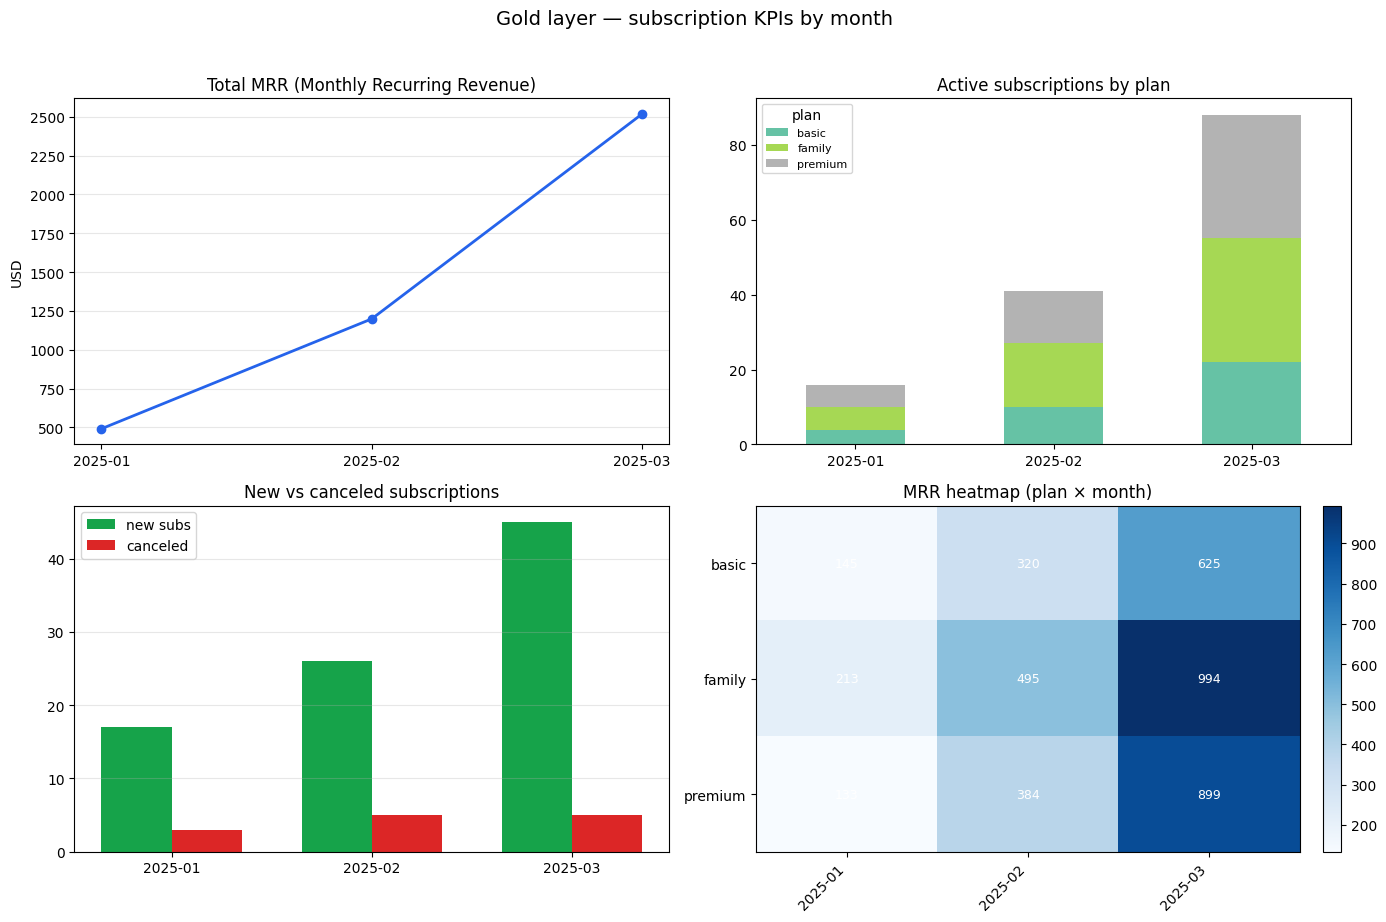

In [8]:
pdf = gold_df.toPandas()
pdf["year_month"] = pd.Categorical(pdf["year_month"], ordered=True)
pdf = pdf.sort_values(["year_month", "plan_type"])

totals = pdf.groupby("year_month", as_index=False).agg(
    mrr=("mrr", "sum"),
    active=("total_active_subs", "sum"),
    new=("new_subs_count", "sum"),
    canceled=("canceled_subs_count", "sum"),
)
months = totals["year_month"].astype(str).tolist()
x = np.arange(len(months))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Gold layer — subscription KPIs by month", fontsize=14, y=1.02)

axes[0, 0].plot(months, totals["mrr"], marker="o", color="#2563eb", linewidth=2)
axes[0, 0].set_title("Total MRR (Monthly Recurring Revenue)")
axes[0, 0].set_ylabel("USD")
axes[0, 0].grid(axis="y", alpha=0.3)

pivot_active = pdf.pivot(index="year_month", columns="plan_type", values="total_active_subs").fillna(0)
pivot_active.plot(kind="bar", stacked=True, ax=axes[0, 1], colormap="Set2")
axes[0, 1].set_title("Active subscriptions by plan")
axes[0, 1].set_xlabel("")
axes[0, 1].legend(title="plan", loc="upper left", fontsize=8)
axes[0, 1].tick_params(axis="x", rotation=0)

w = 0.35
axes[1, 0].bar(x - w / 2, totals["new"], width=w, label="new subs", color="#16a34a")
axes[1, 0].bar(x + w / 2, totals["canceled"], width=w, label="canceled", color="#dc2626")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(months)
axes[1, 0].set_title("New vs canceled subscriptions")
axes[1, 0].legend()
axes[1, 0].grid(axis="y", alpha=0.3)

pivot_mrr = pdf.pivot(index="plan_type", columns="year_month", values="mrr").fillna(0)
im = axes[1, 1].imshow(pivot_mrr.values, aspect="auto", cmap="Blues")
axes[1, 1].set_xticks(range(len(pivot_mrr.columns)))
axes[1, 1].set_xticklabels(pivot_mrr.columns.astype(str), rotation=45, ha="right")
axes[1, 1].set_yticks(range(len(pivot_mrr.index)))
axes[1, 1].set_yticklabels(pivot_mrr.index)
axes[1, 1].set_title("MRR heatmap (plan × month)")
for i in range(len(pivot_mrr.index)):
    for j in range(len(pivot_mrr.columns)):
        val = pivot_mrr.values[i, j]
        axes[1, 1].text(j, i, f"{val:.0f}", ha="center", va="center", color="white", fontsize=9)
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Summary

- Bronze — raw JSON in MinIO, deduplicated, partitioned by event date (`dt`).
- Silver — DQ-filtered CDC with SCD2 history; bad rows in DQE (Data Quality Exceptions).
- Gold — monthly business KPIs for BI and dashboards.

Batch jobs: `apps/` — orchestration: Makefile and Docker Compose.